# Voxel Encoding

In [1]:
%%capture
! pip install himalaya

In [2]:
!pip install --upgrade scipy

You should consider upgrading via the '/gpfs/home1/scur0412/NeuroNLP/neuro/bin/python -m pip install --upgrade pip' command.


In [3]:
import os
import numpy as np
from scipy.io import loadmat
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from scipy.stats import pearsonr
from himalaya.kernel_ridge import KernelRidgeCV
from himalaya.scoring import correlation_score 

In [4]:
# For the .mat files (Experiment 2 and Experiment 3)
mat_exp2 = "/home/scur0412/NeuroNLP/data/participants/M02/data_243sentences.mat"
mat_exp3 = "/home/scur0412/NeuroNLP/data/participants/M02/data_384sentences.mat"

# For the embeddings directories (Experiment 2 and Experiment 3) for Qwen Embedder
embed_dir_exp2 = "/home/scur0412/NeuroNLP/NeuroNLP/results/embeddings/Qwen_Embedder/Experiment2_243"
embed_dir_exp3 = "/home/scur0412/NeuroNLP/NeuroNLP/results/embeddings/Qwen_Embedder/Experiment3_384"

# For the embeddings directories (Experiment 2 and Experiment 3) for Qwen
llm_dir_exp2 = "/home/scur0412/NeuroNLP/NeuroNLP/results/embeddings/Qwen/Experiment2_243"
llm_dir_exp3 = "/home/scur0412/NeuroNLP/NeuroNLP/results/embeddings/Qwen/Experiment3_384"
num_layers = 37

In [5]:
def get_language_responses(mat_path):
    data = loadmat(mat_path, simplify_cells=True)
    target_index = np.where(data['meta']['atlases'] == 'languageLH')[0].item()
    column_indexes = np.concatenate([arr - 1 for arr in data['meta']['roiColumns'][target_index]], axis=0)
    # brain_responses = data['examples_passages'][:, column_indexes]
    brain_responses = data['examples_passagesentences'][:, column_indexes]
    print(f"Dimensionality of brain responses: {brain_responses.shape}")
    return brain_responses

In [6]:
y_exp2 = get_language_responses(mat_exp2)
y_exp3 = get_language_responses(mat_exp3)


/home/scur0412/NeuroNLP/neuro/lib64/python3.9/site-packages/scipy/io/matlab/_mio.py:227: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Consider mio5.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


Dimensionality of brain responses: (243, 4930)
Dimensionality of brain responses: (384, 4930)


In [7]:
Y = np.concatenate([y_exp2, y_exp3], axis=0)

In [8]:
n_splits = 5
kf = KFold(n_splits=n_splits)
alphas = np.logspace(1, 20, 20)
_, n_voxels = Y.shape

layer_performances = {}

In [9]:
# Initialize dictionaries to store performance for both models
layer_performances = {}  # For Qwen model
layer_performances_embedding = {}  # For Qwen Embedding model


for layer_idx in range(num_layers):
    # Load the embeddings for the Qwen model (exp2 and exp3)
    x_exp2 = np.load(os.path.join(llm_dir_exp2, f"qwen_layer{layer_idx}.npy"))
    x_exp3 = np.load(os.path.join(llm_dir_exp3, f"qwen_layer{layer_idx}.npy"))
    X = np.concatenate([x_exp2, x_exp3], axis=0)

    accs_train = np.empty((n_splits, n_voxels))
    accs_test = np.empty((n_splits, n_voxels))

    # Perform cross-validation for Qwen model
    for i, (train_index, test_index) in enumerate(kf.split(X)):
        X_train, X_test = X[train_index, :], X[test_index, :]
        Y_train, Y_test = Y[train_index, :], Y[test_index, :]

        pipeline = make_pipeline(StandardScaler(with_mean=True, with_std=False),
                                 KernelRidgeCV(alphas=alphas, cv=KFold(n_splits=5)))
        
        pipeline.fit(X_train, Y_train)

        preds_train = pipeline.predict(X_train)
        accs_train[i] = correlation_score(Y_train, preds_train)

        preds_test = pipeline.predict(X_test)
        accs_test[i] = correlation_score(Y_test, preds_test)

    # Compute mean test and train accuracies for Qwen model
    mean_test_acc = accs_test.mean(axis=0).mean()
    mean_train_acc = accs_train.mean(axis=0).mean()
    layer_performances[layer_idx] = mean_test_acc
    
    print(f"Qwen Model - Layer {layer_idx} Test Accuracy: {mean_test_acc:.4f}")
    print(f"Qwen Model - Layer {layer_idx} Train Accuracy: {mean_train_acc:.4f}")

    # Now for Qwen Embedding Model - repeat the process with its respective embeddings
    # Load the embeddings for Qwen Embedding model (exp2 and exp3)
    x_exp2_embedding = np.load(os.path.join(embed_dir_exp2, f"qwen_layer{layer_idx}.npy"))
    x_exp3_embedding = np.load(os.path.join(embed_dir_exp3, f"qwen_layer{layer_idx}.npy"))
    X_embedding = np.concatenate([x_exp2_embedding, x_exp3_embedding], axis=0)

    accs_train_embedding = np.empty((n_splits, n_voxels))
    accs_test_embedding = np.empty((n_splits, n_voxels))

    # Perform cross-validation for Qwen Embedding model
    for i, (train_index, test_index) in enumerate(kf.split(X_embedding)):
        X_train, X_test = X_embedding[train_index, :], X_embedding[test_index, :]
        Y_train, Y_test = Y[train_index, :], Y[test_index, :]

        pipeline = make_pipeline(StandardScaler(with_mean=True, with_std=False),
                                 KernelRidgeCV(alphas=alphas, cv=KFold(n_splits=5)))
        
        pipeline.fit(X_train, Y_train)

        preds_train = pipeline.predict(X_train)
        accs_train_embedding[i] = correlation_score(Y_train, preds_train)

        preds_test = pipeline.predict(X_test)
        accs_test_embedding[i] = correlation_score(Y_test, preds_test)

    # Compute mean test and train accuracies for Qwen Embedding model
    mean_test_acc_embedding = accs_test_embedding.mean(axis=0).mean()
    mean_train_acc_embedding = accs_train_embedding.mean(axis=0).mean()
    layer_performances_embedding[layer_idx] = mean_test_acc_embedding
    
    print(f"Qwen Embedding Model - Layer {layer_idx} Test Accuracy: {mean_test_acc_embedding:.4f}")
    print(f"Qwen Embedding Model - Layer {layer_idx} Train Accuracy: {mean_train_acc_embedding:.4f}")

FileNotFoundError: [Errno 2] No such file or directory: '/home/scur0412/NeuroNLP/NeuroNLP/results/embeddings/Qwen/Experiment2_243/qwen_layer0.npy'

In [ ]:
output_dir = "/home/scur0410/NeuroNLP/NeuroNLP/results"
os.makedirs(output_dir, exist_ok=True)

output_file = os.path.join(output_dir, "qwen_layer_performances.npy")
np.save(output_file, layer_performances)

output_file_embedding = os.path.join(output_dir, "qwen_embedding_layer_performances.npy")
np.save(output_file_embedding, layer_performances_embedding)

In [ ]:
output_dir = "/home/scur0412/NeuroNLP/results"
output_file = os.path.join(output_dir, "qwen_layer_performances.npy")

qwen_embedding_output_file = os.path.join(output_dir, "qwen_embedding_layer_performances.npy")

In [ ]:
%pip install matplotlib

  Using cached matplotlib-3.9.4-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (8.3 MB)
  Using cached importlib_resources-6.5.2-py3-none-any.whl (37 kB)
  Using cached pillow-11.3.0-cp39-cp39-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (6.6 MB)
     |████████████████████████████████| 122 kB 24.4 MB/s            
  Using cached fonttools-4.60.2-cp39-cp39-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (4.8 MB)
  Using cached contourpy-1.3.0-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (321 kB)
  Using cached kiwisolver-1.4.7-cp39-cp39-manylinux_2_12_x86_64.manylinux2010_x86_64.whl (1.6 MB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
You should consider upgrading via the '/home/scur0410/NeuroNLP/NeuroNLP/neuroai/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


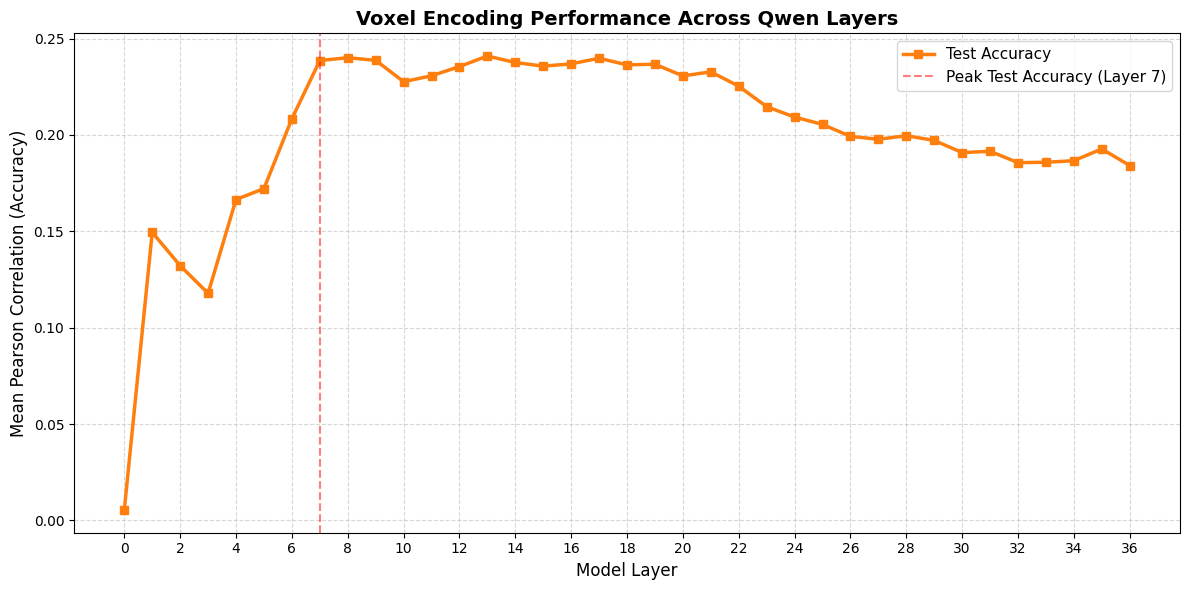

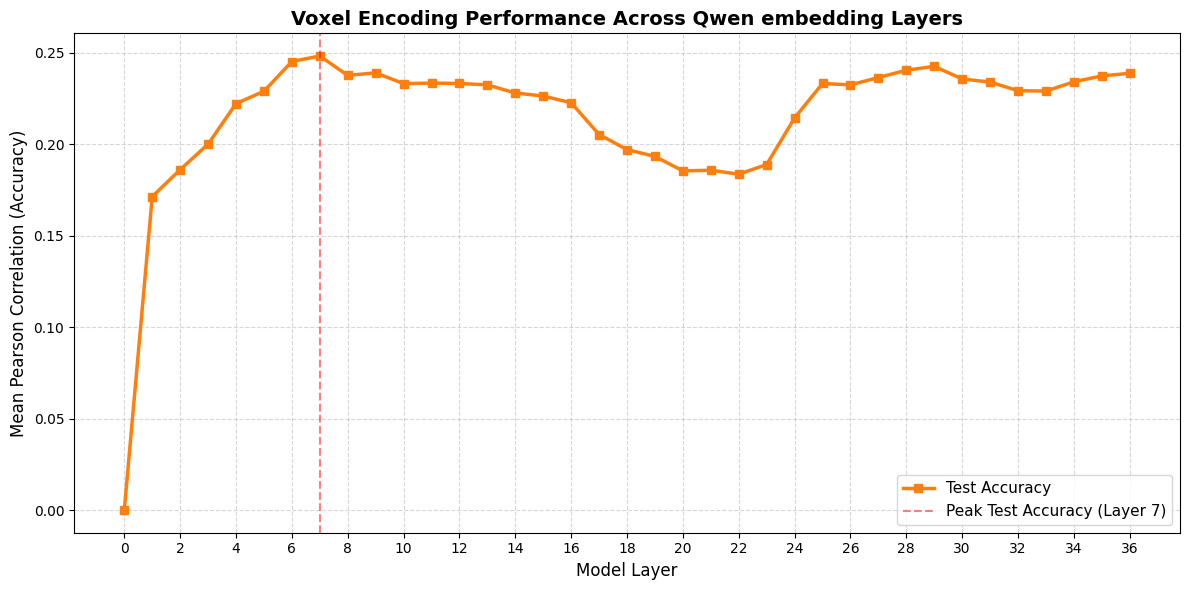

In [ ]:
layer_performances = np.load(output_file, allow_pickle=True).item()

layers = sorted(layer_performances.keys())
test_acc = [layer_performances[layer] for layer in layers]

plt.figure(figsize=(12, 6))

plt.plot(layers, test_acc, marker='s', label='Test Accuracy', color='#ff7f0e', linewidth=2.5, linestyle='-')

plt.axvline(x=7, color='red', linestyle='--', alpha=0.5, label='Peak Test Accuracy (Layer 7)')

plt.title("Voxel Encoding Performance Across Qwen Layers", fontsize=14, fontweight='bold')
plt.xlabel("Model Layer", fontsize=12)
plt.ylabel("Mean Pearson Correlation (Accuracy)", fontsize=12)
plt.xticks(np.arange(0, len(layers), 2))
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

layer_performances = np.load(
output_file_embedding, allow_pickle=True).item()

layers = sorted(layer_performances.keys())
test_acc = [layer_performances[layer] for layer in layers]

plt.figure(figsize=(12, 6))

plt.plot(layers, test_acc, marker='s', label='Test Accuracy', color='#ff7f0e', linewidth=2.5, linestyle='-')

plt.axvline(x=7, color='red', linestyle='--', alpha=0.5, label='Peak Test Accuracy (Layer 7)')

plt.title("Voxel Encoding Performance Across Qwen embedding Layers", fontsize=14, fontweight='bold')
plt.xlabel("Model Layer", fontsize=12)
plt.ylabel("Mean Pearson Correlation (Accuracy)", fontsize=12)
plt.xticks(np.arange(0, len(layers), 2))
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

For All Particpants

In [12]:
participants = ["M02", "M03", "M04", "M07", "M08", "M09", "M14", "M15", "P01"]
num_layers = 37
n_splits = 5
kf = KFold(n_splits=n_splits)
alphas = np.logspace(1, 20, 20)

embed_dir_exp2 = "/home/scur0412/NeuroNLP/results/embeddings/Qwen_Embedder/Experiment2_243"
embed_dir_exp3 = "/home/scur0412/NeuroNLP/results/embeddings/Qwen_Embedder/Experiment3_384"
llm_dir_exp2 = "/home/scur0412/NeuroNLP/results/embeddings/Qwen/Experiment2_243"
llm_dir_exp3 = "/home/scur0412/NeuroNLP/results/embeddings/Qwen/Experiment3_384"

In [13]:
all_accs_qwen_exp2 = np.zeros((len(participants), num_layers))
all_accs_qwen_exp3 = np.zeros((len(participants), num_layers))
all_accs_embedder_exp2 = np.zeros((len(participants), num_layers))
all_accs_embedder_exp3 = np.zeros((len(participants), num_layers))

In [14]:
def run_cv_pipeline(X, Y):
    _, n_voxels = Y.shape
    accs_train = np.empty((n_splits, n_voxels))
    accs_test = np.empty((n_splits, n_voxels))

    for i, (train_index, test_index) in enumerate(kf.split(X)):
        X_train, X_test = X[train_index, :], X[test_index, :]
        Y_train, Y_test = Y[train_index, :], Y[test_index, :]

        pipeline = make_pipeline(StandardScaler(with_mean=True, with_std=False),
                                 KernelRidgeCV(alphas=alphas, cv=KFold(n_splits=5)))
        
        pipeline.fit(X_train, Y_train)

        preds_train = pipeline.predict(X_train)
        accs_train[i] = correlation_score(Y_train, preds_train)

        preds_test = pipeline.predict(X_test)
        accs_test[i] = correlation_score(Y_test, preds_test)

    mean_test_acc = accs_test.mean(axis=0).mean()
    mean_train_acc = accs_train.mean(axis=0).mean()
    
    return mean_test_acc, mean_train_acc

In [20]:
brain_data = {}
for participant in participants:
    print(f"data for {participant}...")
    brain_data[participant] = {'exp2': None, 'exp3': None}
    mat_exp2 = f"/home/scur0412/NeuroNLP/data/participants/{participant}/data_243sentences.mat"
    mat_exp3 = f"/home/scur0412/NeuroNLP/data/participants/{participant}/data_384sentences.mat"
    
    if os.path.exists(mat_exp2):
        brain_data[participant]['exp2'] = get_language_responses(mat_exp2)
    else:
        print(f"Missing Exp 2 data for {participant}")

    if os.path.exists(mat_exp3):
        brain_data[participant]['exp3'] = get_language_responses(mat_exp3)
    else:
        print(f" Missing Exp 3 data for {participant}")

data for M02...
Dimensionality of brain responses: (243, 4930)
Dimensionality of brain responses: (384, 4930)
data for M03...
Dimensionality of brain responses: (243, 3616)
 Missing Exp 3 data for M03
data for M04...
Dimensionality of brain responses: (243, 5906)
Dimensionality of brain responses: (384, 5906)
data for M07...
Dimensionality of brain responses: (243, 5629)
Dimensionality of brain responses: (384, 5629)
data for M08...
Missing Exp 2 data for M08
Dimensionality of brain responses: (384, 5083)
data for M09...
Missing Exp 2 data for M09
Dimensionality of brain responses: (384, 3513)
data for M14...
Missing Exp 2 data for M14
Dimensionality of brain responses: (384, 5225)
data for M15...
Missing Exp 2 data for M15
 Missing Exp 3 data for M15
data for P01...
Dimensionality of brain responses: (243, 5265)
Dimensionality of brain responses: (384, 5265)


In [35]:
for layer_idx in range(num_layers):  
    print(f"Layer {layer_idx}")

    x_qwen_exp2 = np.load(os.path.join(llm_dir_exp2, f"qwen_layer{layer_idx}.npy"))
    x_qwen_exp3 = np.load(os.path.join(llm_dir_exp3, f"qwen_layer{layer_idx}.npy"))
    x_emb_exp2  = np.load(os.path.join(embed_dir_exp2, f"qwen_layer{layer_idx}.npy"))
    x_emb_exp3  = np.load(os.path.join(embed_dir_exp3, f"qwen_layer{layer_idx}.npy"))

    for p_idx, participant in enumerate(participants):

        y_exp2 = brain_data[participant]['exp2']
        y_exp3 = brain_data[participant]['exp3']

        if y_exp2 is not None:
            test_qwen_e2, _ = run_cv_pipeline(x_qwen_exp2, y_exp2)
            all_accs_qwen_exp2[p_idx, layer_idx] = test_qwen_e2

            test_emb_e2, _ = run_cv_pipeline(x_emb_exp2, y_exp2)
            all_accs_embedder_exp2[p_idx, layer_idx] = test_emb_e2

        if y_exp3 is not None:
            test_qwen_e3, _ = run_cv_pipeline(x_qwen_exp3, y_exp3)
            all_accs_qwen_exp3[p_idx, layer_idx] = test_qwen_e3

            test_emb_e3, _ = run_cv_pipeline(x_emb_exp3, y_exp3)
            all_accs_embedder_exp3[p_idx, layer_idx] = test_emb_e3

Layer 0
Layer 1
Layer 2
Layer 3
Layer 4
Layer 5
Layer 6
Layer 7
Layer 8
Layer 9
Layer 10
Layer 11
Layer 12
Layer 13
Layer 14
Layer 15
Layer 16
Layer 17
Layer 18
Layer 19
Layer 20
Layer 21
Layer 22
Layer 23
Layer 24
Layer 25
Layer 26
Layer 27
Layer 28
Layer 29
Layer 30
Layer 31
Layer 32
Layer 33
Layer 34
Layer 35
Layer 36


In [36]:
output_dir = "/home/scur0412/NeuroNLP/results"
os.makedirs(output_dir, exist_ok=True)

np.save(os.path.join(output_dir, "qwen_layer_performances_exp2.npy"), all_accs_qwen_exp2)
np.save(os.path.join(output_dir, "qwen_embedding_layer_performances_exp2.npy"), all_accs_embedder_exp2)
np.save(os.path.join(output_dir, "qwen_layer_performances_exp3.npy"), all_accs_qwen_exp3)
np.save(os.path.join(output_dir, "qwen_embedding_layer_performances_exp3.npy"), all_accs_embedder_exp3)

In [30]:
import matplotlib.pyplot as plt

In [24]:
def plot_all_participants(data_matrix, title):
    plt.figure(figsize=(12, 6))
    
    for p_idx, participant in enumerate(participants):
        if np.all(np.isnan(data_matrix[p_idx])):
            continue
            
        plt.plot(layers, data_matrix[p_idx, :], marker='.', label=participant, 
                 color=colors[p_idx], linewidth=1.5, alpha=0.8)

    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Model Layer", fontsize=12)
    plt.ylabel("Mean Pearson Correlation", fontsize=12)
    plt.xticks(np.arange(0, num_layers, 2))
    plt.legend(title="Participants", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [25]:
def plot_averages(qwen_matrix, embedder_matrix, exp_name):
    avg_qwen = np.nanmean(qwen_matrix, axis=0)
    avg_embedder = np.nanmean(embedder_matrix, axis=0)

    plt.figure(figsize=(12, 6))
    plt.plot(layers, avg_qwen, marker='s', label='LLM (Average)', color='#1f77b4', linewidth=3)
    plt.plot(layers, avg_embedder, marker='o', label='Embedder (Average)', color='#ff7f0e', linewidth=3)

    plt.title(f"Average Performance: LLM vs. Embedder ({exp_name})", fontsize=14, fontweight='bold')
    plt.xlabel("Model Layer", fontsize=12)
    plt.ylabel("Mean Pearson Correlation", fontsize=12)
    plt.xticks(np.arange(0, num_layers, 2))
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [37]:
accs_qwen_exp2 = np.load(os.path.join(output_dir, "qwen_layer_performances_exp2.npy"))
accs_emb_exp2 = np.load(os.path.join(output_dir, "qwen_embedding_layer_performances_exp2.npy"))
accs_qwen_exp3 = np.load(os.path.join(output_dir, "qwen_layer_performances_exp3.npy"))
accs_emb_exp3 = np.load(os.path.join(output_dir, "qwen_embedding_layer_performances_exp3.npy"))

In [38]:
layers = np.arange(num_layers)  
colors = plt.cm.tab10.colors

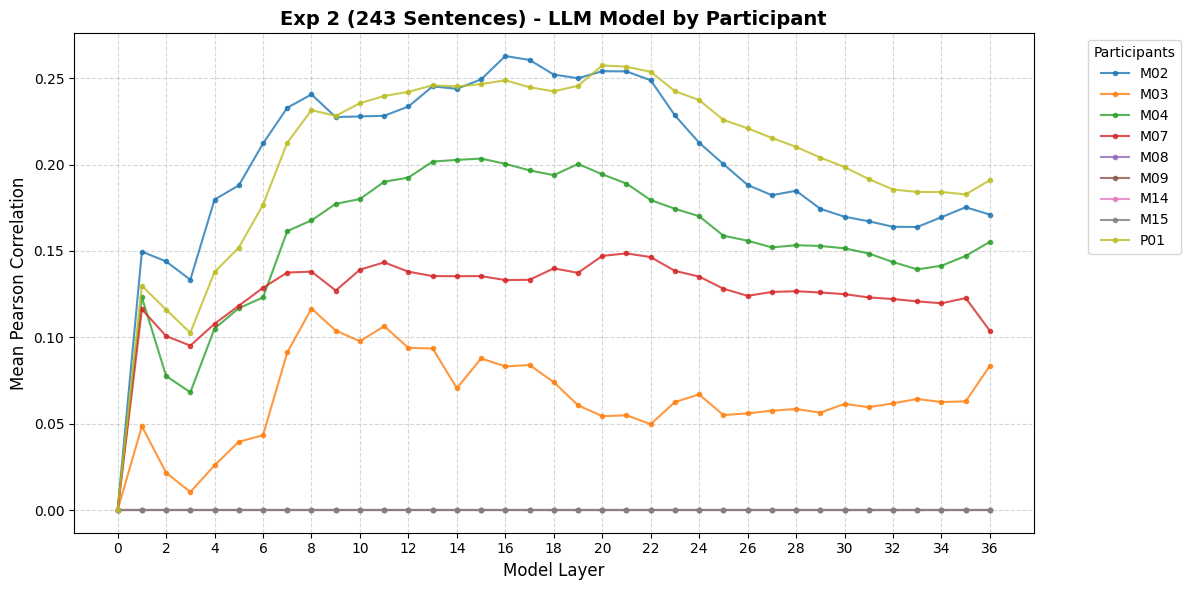

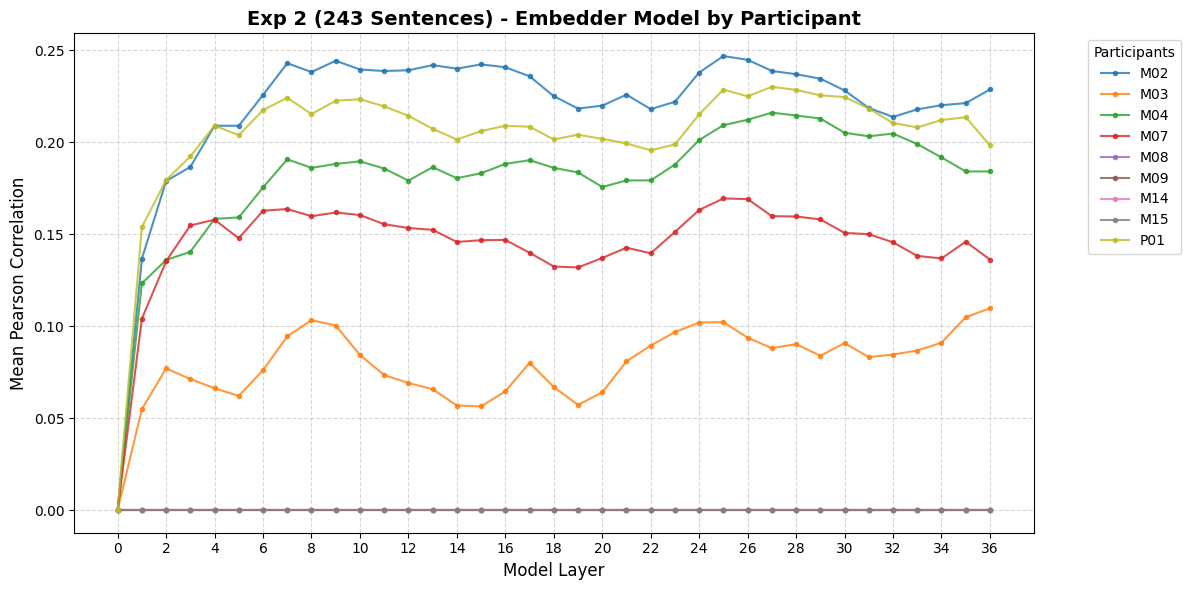

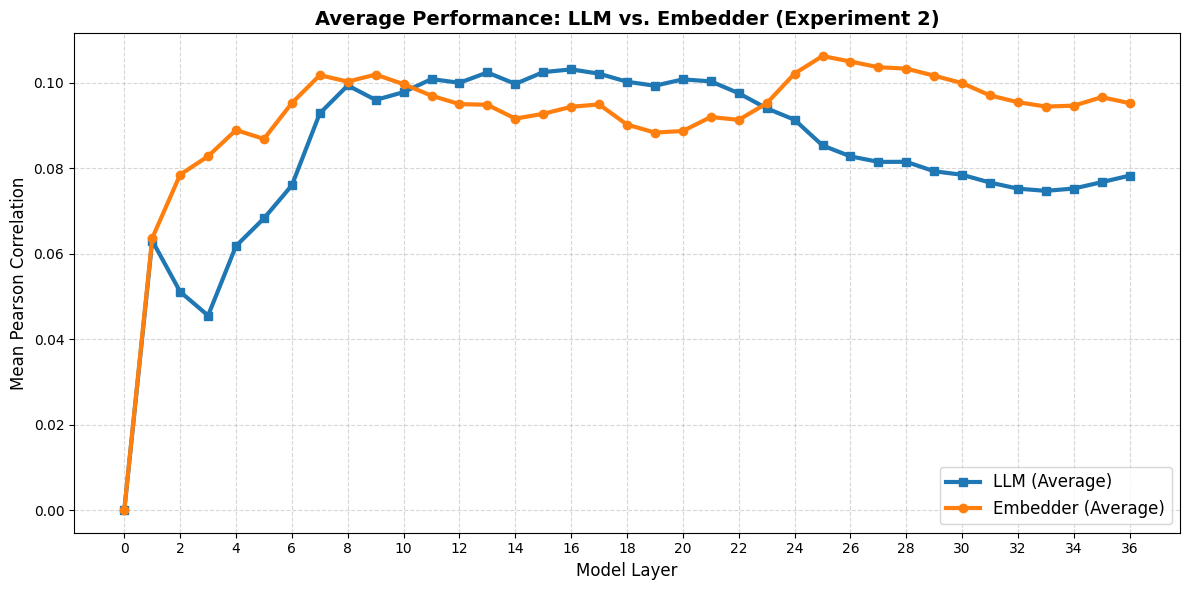

In [39]:
plot_all_participants(accs_qwen_exp2, "Exp 2 (243 Sentences) - LLM Model by Participant")
plot_all_participants(accs_emb_exp2, "Exp 2 (243 Sentences) - Embedder Model by Participant")
plot_averages(accs_qwen_exp2, accs_emb_exp2, "Experiment 2")

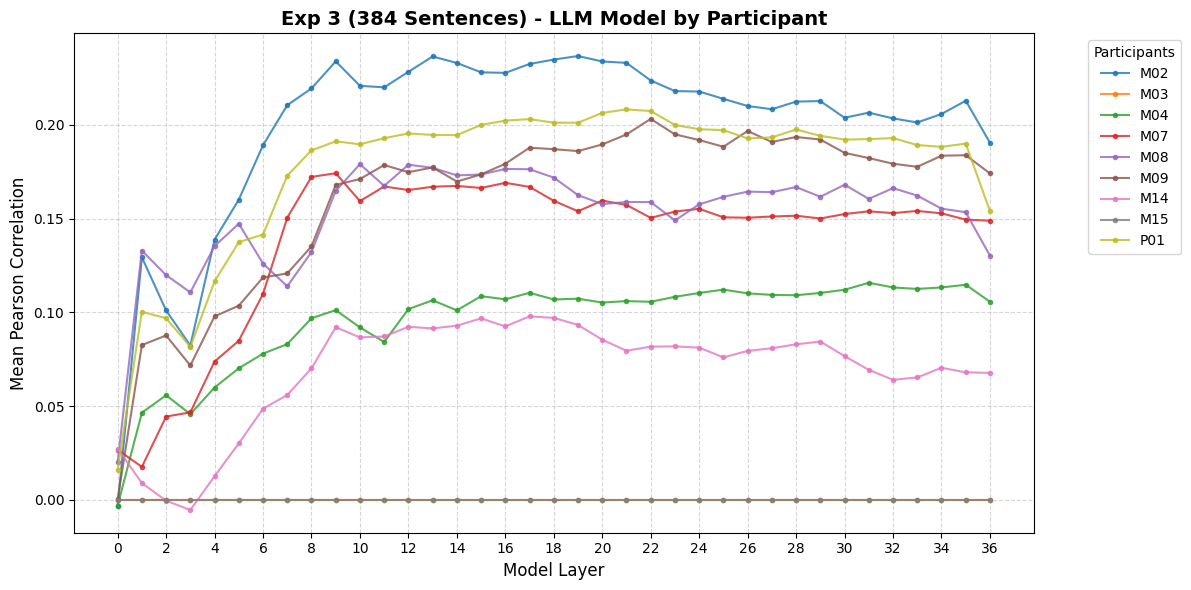

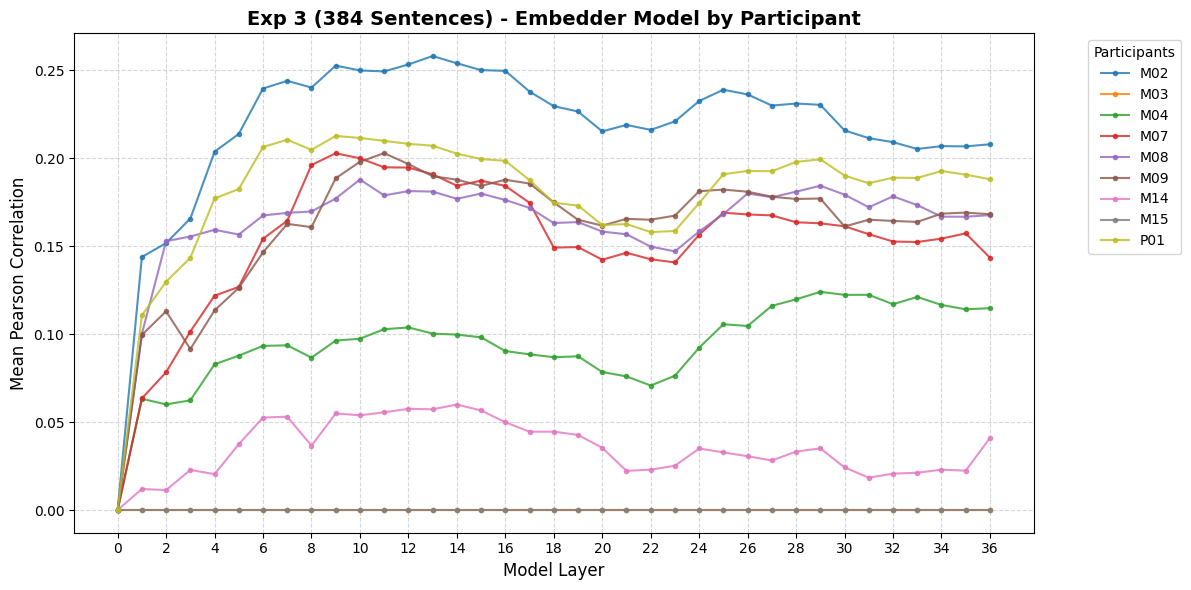

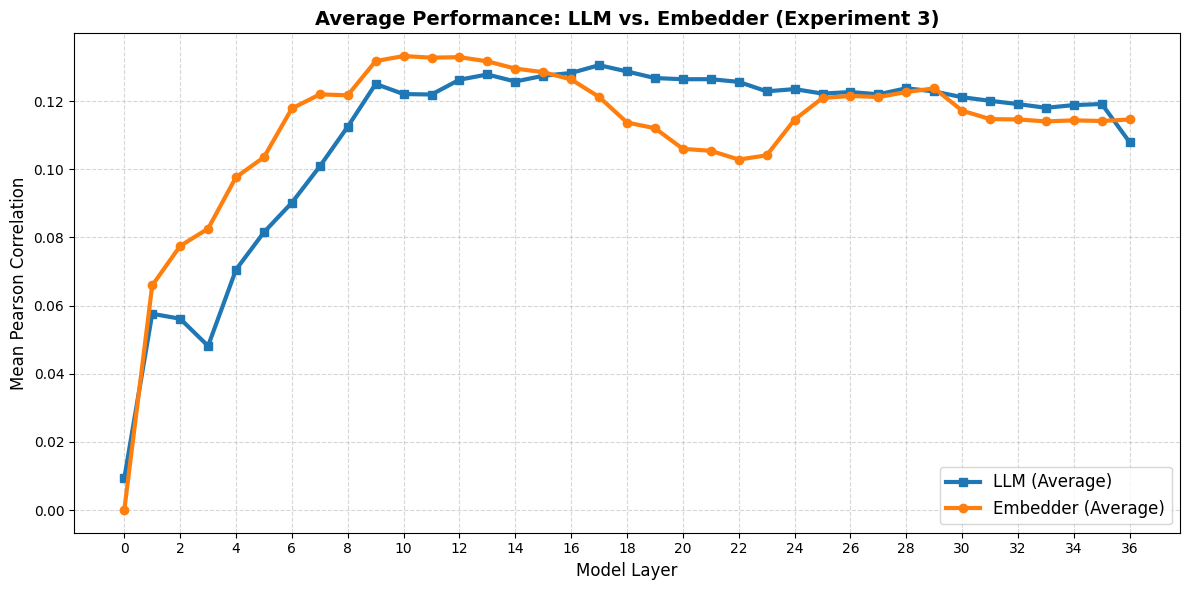

In [40]:
plot_all_participants(accs_qwen_exp3, "Exp 3 (384 Sentences) - LLM Model by Participant")
plot_all_participants(accs_emb_exp3, "Exp 3 (384 Sentences) - Embedder Model by Participant")
plot_averages(accs_qwen_exp3, accs_emb_exp3, "Experiment 3")